#Path'Ora — Data Science Pipeline
## Coding Camp 2026 powered by DBS Foundation

| Info | Detail |
|------|--------|
| **Tim** | CC26-PSU344 |
| **Tema** | Future Ready Work & Economy |
| **Proyek** | Path'Ora — Platform End-to-End Kesiapan Kerja |
| **Learning Path** | Data Science |
| **Dataset** | Kaggle Resume Dataset |

### Alur Pipeline
```
1. Setup & Import  →  2. Load Data  →  3. Data Assessing
4. Data Cleaning   →  5. EDA        →  6. Feature Engineering
7. Labeling        →  8. Modeling   →  9. Evaluasi & Insight
```

Proyek ini, bernama **Path'Ora**, adalah bagian dari Coding Camp 2026. Tujuannya adalah membangun platform end-to-end untuk mengukur kesiapan kerja seseorang berdasarkan resume mereka. Pipeline Data Science yang digunakan meliputi Setup, Load Data, Data Assessing, Data Cleaning, EDA, Feature Engineering, Labeling, Modeling, dan Evaluasi.

---
## 1. Setup & Import Library

Di bagian ini, semua *library* Python yang dibutuhkan untuk proyek diimpor. Ini termasuk:  
- **Core Libraries**: `pandas` untuk manipulasi data, `numpy` untuk operasi numerik.  
- **Visualisasi**: `matplotlib` dan `seaborn` untuk membuat grafik dan plot.  
- **Preprocessing**: `sklearn.preprocessing` untuk *encoding* dan *scaling* data, `sklearn.model_selection` untuk membagi data dan *cross-validation*.  
- **Model**: Berbagai algoritma klasifikasi dari `sklearn.linear_model`, `sklearn.tree`, `sklearn.ensemble`, `sklearn.neighbors`, `sklearn.svm`, `sklearn.naive_bayes`.  
- **Evaluasi**: Metrik evaluasi model seperti `accuracy_score`, `f1_score`, `roc_auc_score` dari `sklearn.metrics`.  
- **Imbalanced Learning**: `SMOTE` dari `imblearn` untuk menangani ketidakseimbangan kelas dalam data.  
- Juga diatur `RANDOM_STATE` untuk reproduktibilitas hasil dan *styling* plot.

In [3]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print('⚠ imbalanced-learn tidak tersedia, SMOTE dilewati.')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

RANDOM_STATE = 42
print('Semua library berhasil di-import.')

Semua library berhasil di-import.


---
## 2. Load Dataset

Pada tahap ini, dataset `Resume.csv` dimuat ke dalam DataFrame pandas bernama `df_raw`. Kemudian, ditampilkan jumlah baris dan kolom serta 3 baris pertama data untuk pemeriksaan awal. Dataset ini berisi `ID`, `Resume_str` (teks resume), `Resume_html` (versi HTML resume), dan `Category` (kategori pekerjaan).

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#Load dataset
CSV_PATH = '/content/drive/MyDrive/Pathora Capstone Project/Resume.csv'
df_raw = pd.read_csv(CSV_PATH)

print(f' Dataset berhasil dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
df_raw.head(3)

 Dataset berhasil dimuat: 2,484 baris × 4 kolom


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


---
## 3. Data Assessing (Penilaian Kualitas Data)

Bagian ini berfokus pada penilaian kualitas data (`df_raw`) untuk mengidentifikasi masalah seperti:  
- **Informasi Umum**: Mengecek tipe data dan jumlah nilai non-null untuk setiap kolom (`df_raw.info()`).  
- **Missing Values**: Memeriksa apakah ada nilai yang hilang (`isnull().sum()`).  
- **Duplikasi**: Mendeteksi adanya baris yang terduplikasi (`duplicated().sum()`).  
- **Distribusi Kategori**: Melihat sebaran jumlah resume untuk setiap kategori pekerjaan (`value_counts()`), menunjukkan ada 24 kategori unik.  
- **Statistik Deskriptif Panjang Resume**: Menghitung jumlah kata dalam setiap resume (`word_count_raw`) dan menampilkan statistik ringkasnya (rata-rata, median, min, max, dll.) serta distribusinya dalam bentuk histogram.

In [6]:
print('=' * 55)
print('  INFO DATASET')
print('=' * 55)
df_raw.info()
print()
print('Missing Values:')
print(df_raw.isnull().sum())
print()
print(f'Jumlah duplikat: {df_raw.duplicated().sum()}')
print()
print('Distribusi Kategori (Target Rekomendasi):')
print(df_raw['Category'].value_counts())

  INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Jumlah duplikat: 0

Distribusi Kategori (Target Rekomendasi):
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION          

── Statistik panjang resume (kata) ─────────────────────
count    2484.0
mean      811.3
std       371.0
min         0.0
25%       651.0
50%       757.0
75%       933.0
max      5190.0
Name: word_count_raw, dtype: float64


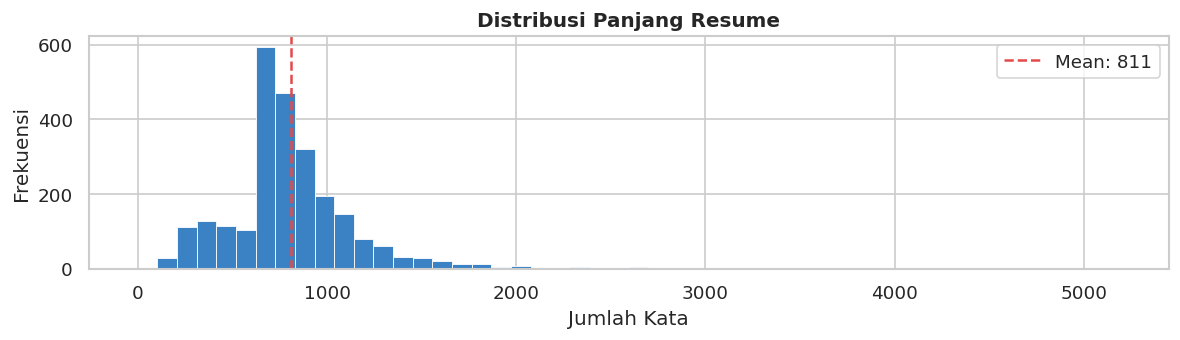

In [7]:
# Statistik deskriptif panjang resume
df_raw['word_count_raw'] = df_raw['Resume_str'].str.split().str.len()
print('── Statistik panjang resume (kata) ─────────────────────')
print(df_raw['word_count_raw'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(df_raw['word_count_raw'], bins=50, color='#3B82C4', edgecolor='white', linewidth=0.5)
ax.axvline(df_raw['word_count_raw'].mean(), color='#E24B4A', linestyle='--', label=f'Mean: {df_raw["word_count_raw"].mean():.0f}')
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Panjang Resume', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Data Cleaning

Tahap *data cleaning* ini bertujuan untuk menyempurnakan dataset agar siap untuk analisis lebih lanjut:  
- **Duplikasi DataFrame**: Membuat salinan `df_raw` menjadi `df` agar perubahan tidak memengaruhi data asli.  
- **Penghapusan Kolom**: Kolom `Resume_html` dihapus karena tidak akan digunakan dalam analisis teks.  
- **Filter Resume Pendek**: Baris resume yang sangat pendek (kurang dari 50 kata) dihapus karena dianggap tidak informatif.  
- **Normalisasi Whitespace**: Membersihkan spasi berlebih dalam teks resume.  
- **Normalisasi Kategori**: Mengubah nama kategori menjadi huruf kapital dan menghapus spasi di awal/akhir untuk konsistensi.  
- **Kolom Lowercase**: Membuat kolom `resume_lower` yang berisi teks resume dalam huruf kecil untuk memudahkan ekstraksi fitur berbasis kata kunci.

In [8]:
df = df_raw.copy()

# 4.1 Drop kolom Resume_html (tidak digunakan untuk analisis teks)
df.drop(columns=['Resume_html'], inplace=True)

# 4.2 Hapus baris dengan Resume_str kosong atau sangat pendek (< 50 kata)
df['word_count_raw'] = df['Resume_str'].str.split().str.len()
before = len(df)
df = df[df['word_count_raw'] >= 50].reset_index(drop=True)
print(f'Baris dihapus karena terlalu pendek (<50 kata): {before - len(df)}')

# 4.3 Bersihkan whitespace berlebih di teks resume
df['Resume_str'] = df['Resume_str'].str.replace(r'\s+', ' ', regex=True).str.strip()

# 4.4 Normalisasi nama kategori (uppercase, strip)
df['Category'] = df['Category'].str.upper().str.strip()

# 4.5 Buat kolom lowercase untuk ekstraksi fitur
df['resume_lower'] = df['Resume_str'].str.lower()

print(f'\n Dataset setelah cleaning: {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Missing values tersisa: {df.isnull().sum().sum()}')

Baris dihapus karena terlalu pendek (<50 kata): 1

 Dataset setelah cleaning: 2,483 baris × 5 kolom
Missing values tersisa: 0


---
## 5. Exploratory Data Analysis (EDA)

Eksplorasi Data Analisis (EDA) dilakukan untuk mendapatkan wawasan lebih dalam tentang karakteristik data setelah proses *cleaning*:  
- **Distribusi Kategori Pekerjaan**: Memvisualisasikan jumlah resume untuk setiap kategori, menunjukkan kategori mana yang paling banyak/sedikit.  
- **Analisis Panjang Resume per Kategori**: Menggunakan *boxplot* untuk membandingkan distribusi panjang resume (jumlah kata) antar kategori pekerjaan, membantu melihat apakah ada perbedaan signifikan.  
- **Analisis Frekuensi Kata Kunci**: Menghitung persentase resume yang mengandung kata kunci tertentu (misalnya 'Excel', 'Python', 'Leadership', 'Bachelor') dan memvisualisasikannya, memberikan gambaran tentang *skill* dan kualifikasi umum yang ada di dataset.

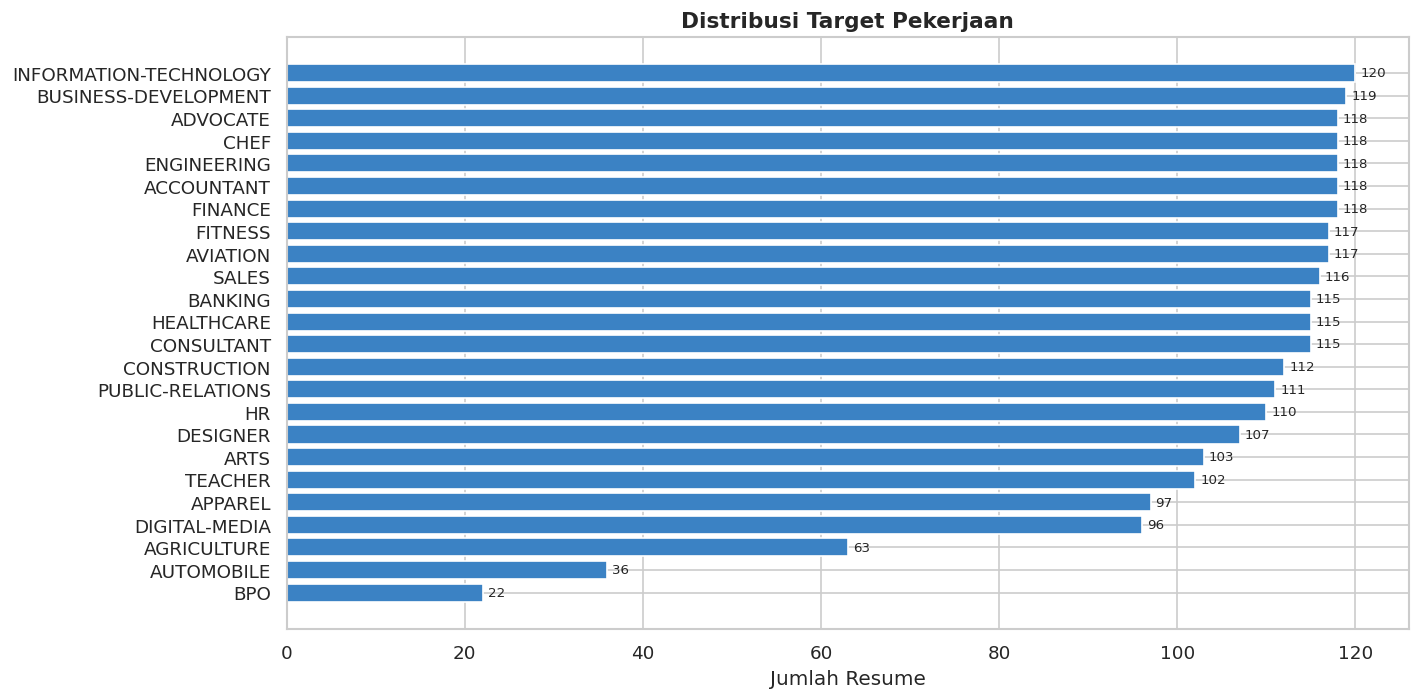

Total kategori: 24


In [9]:
# ── 5.1 Distribusi kategori pekerjaan ──────────────────────────────
cat_counts = df['Category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cat_counts.index, cat_counts.values, color='#3B82C4', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel('Jumlah Resume')
ax.set_title('Distribusi Target Pekerjaan', fontweight='bold', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f'Total kategori: {df["Category"].nunique()}')

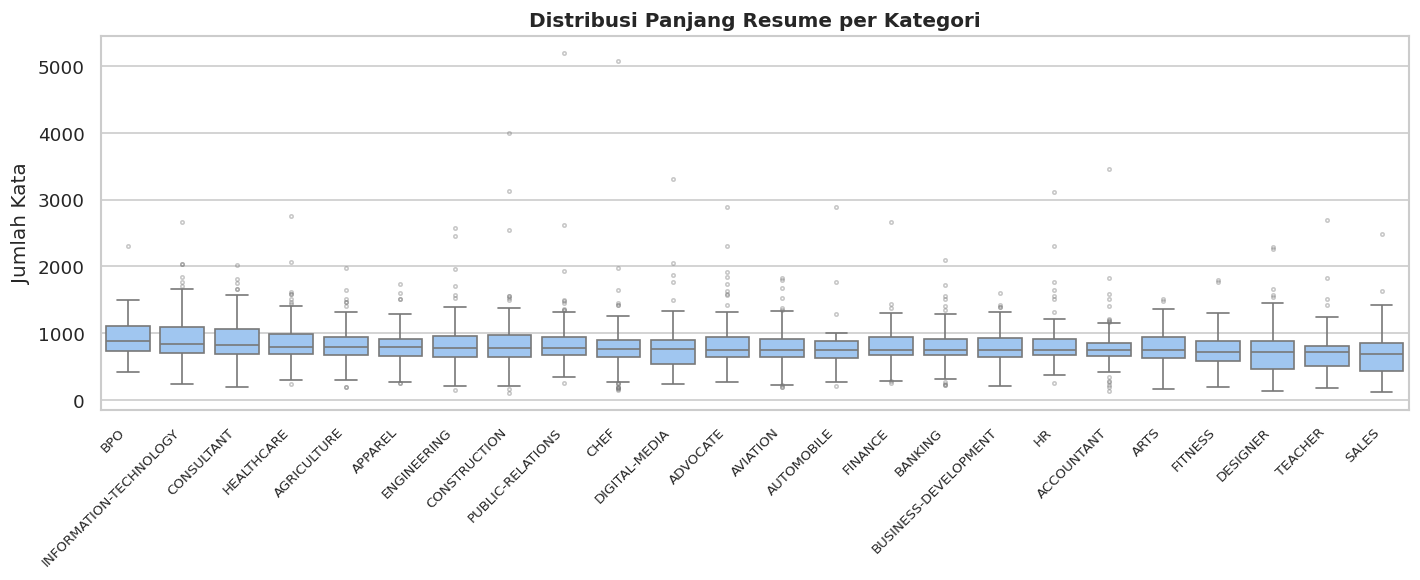

In [10]:
# ── 5.2 Analisis panjang resume per kategori ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
order = df.groupby('Category')['word_count_raw'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Category', y='word_count_raw', order=order, ax=ax,
            color='#93C5FD', flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.4})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('Jumlah Kata')
ax.set_title('Distribusi Panjang Resume per Kategori', fontweight='bold')
plt.tight_layout()
plt.show()

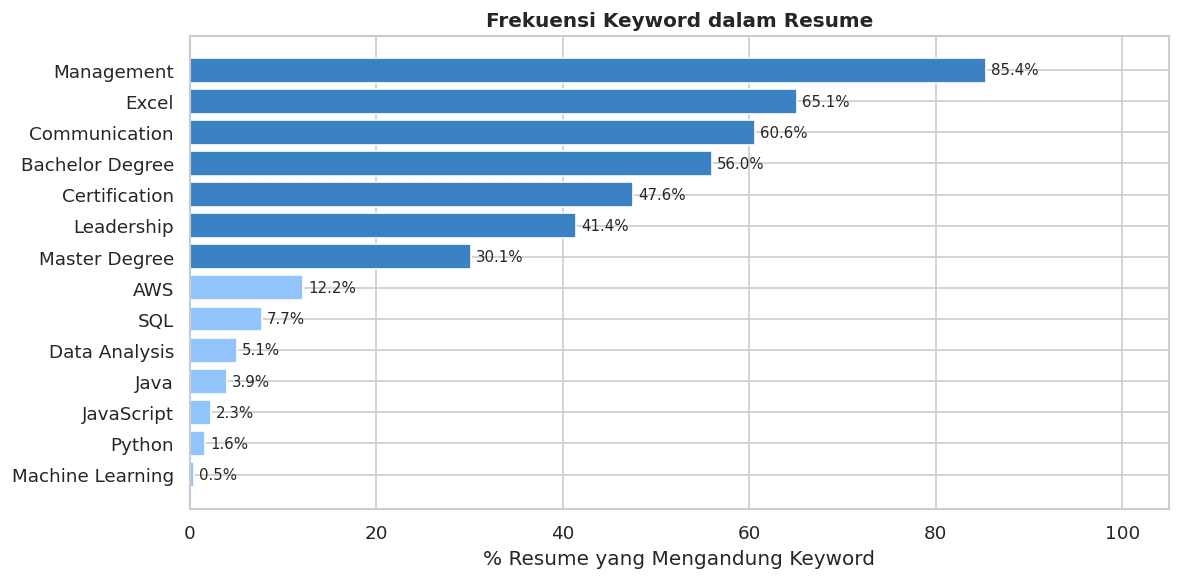

In [11]:
# ── 5.3 Keyword frequency analysis ─────────────────────────────────
keywords = {
    'excel': 'Excel', 'communication': 'Communication', 'management': 'Management',
    'leadership': 'Leadership', 'sql': 'SQL', 'python': 'Python',
    'java': 'Java', 'javascript': 'JavaScript', 'aws': 'AWS',
    'machine learning': 'Machine Learning', 'data analysis': 'Data Analysis',
    'certif': 'Certification', 'bachelor': 'Bachelor Degree', 'master': 'Master Degree'
}

keyword_pct = {
    label: (df['resume_lower'].str.contains(kw).sum() / len(df) * 100)
    for kw, label in keywords.items()
}
kw_df = pd.Series(keyword_pct).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3B82C4' if v >= 20 else '#93C5FD' for v in kw_df.values]
bars = ax.barh(kw_df.index, kw_df.values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('% Resume yang Mengandung Keyword')
ax.set_title('Frekuensi Keyword dalam Resume', fontweight='bold')
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

---
## 6. Feature Engineering

Pada tahap ini, fitur-fitur baru direkayasa dari kolom `Resume_str` untuk menjadi input model. Didefinisikan daftar *technical skills* (`TECH_SKILLS`) dan *soft skills* (`SOFT_SKILLS`).  
Kemudian, dibuat beberapa fungsi:  
- `get_edu_level`: Mengubah tingkat pendidikan (PhD, Master, Bachelor, Associate/Diploma) menjadi nilai ordinal (0-4).  
- `get_max_experience`: Mengekstrak tahun pengalaman kerja terbesar yang disebutkan dalam resume.  
- `has_certification`: Mendeteksi apakah resume menyebutkan 'sertifikasi'.  
- `count_tech_skills` & `count_soft_skills`: Menghitung jumlah *technical* atau *soft skills* yang terdeteksi dari daftar kata kunci.  
Fitur-fitur ini kemudian diterapkan ke DataFrame untuk membuat kolom baru seperti `edu_level`, `years_experience`, `has_cert`, `tech_skill_count`, `soft_skill_count`, `word_count`, dan `char_count`. Distribusi fitur-fitur yang diekstrak ini kemudian divisualisasikan dengan berbagai plot (bar chart, histogram) untuk memahami sebarannya.

In [12]:
# ═══════════════════════════════════════════════════════════════
#  DAFTAR KEYWORD
# ═══════════════════════════════════════════════════════════════
TECH_SKILLS = [
    'python', 'sql', 'java', 'javascript', 'excel', 'powerpoint',
    'tableau', 'machine learning', 'data analysis', 'cloud', 'aws',
    'azure', 'docker', 'react', 'angular', 'nodejs', 'tensorflow',
    'pytorch', 'r programming', 'hadoop', 'spark', 'nlp',
    'deep learning', 'css', 'html', 'linux'
]

SOFT_SKILLS = [
    'leadership', 'management', 'communication', 'teamwork', 'collaboration',
    'problem.solving', 'analytical', 'creative', 'adaptab', 'time management',
    'presentation', 'negotiat', 'strategic', 'innovat'
]

# ═══════════════════════════════════════════════════════════════
#  FUNGSI EKSTRAKSI FITUR
# ═══════════════════════════════════════════════════════════════

def get_edu_level(text: str) -> int:
    if re.search(r'ph\.?d|doctorate', text): return 4
    if re.search(r'master|m\.s\.|m\.a\.|mba', text):  return 3
    if re.search(r'bachelor|b\.s\.|b\.a\.|undergraduate', text): return 2
    if re.search(r'associate|diploma', text): return 1
    return 0

def get_edu_label(level: int) -> str:
    mapping = {0: 'Tidak ada', 1: 'Associate/Diploma', 2: 'Bachelor', 3: 'Master', 4: 'PhD'}
    return mapping[level]

def get_max_experience(text: str) -> int:
    matches = re.findall(r'(\d+)[+]?\s+year[s]?\s+(?:of\s+)?experience', text)
    return max((int(x) for x in matches), default=0)

def has_certification(text: str) -> int:
    return int(bool(re.search(r'certif', text)))

def count_tech_skills(text: str) -> int:
    return sum(1 for skill in TECH_SKILLS if re.search(skill, text))

def count_soft_skills(text: str) -> int:
    return sum(1 for skill in SOFT_SKILLS if re.search(skill, text))

# ═══════════════════════════════════════════════════════════════
#  TERAPKAN KE DATAFRAME
# ═══════════════════════════════════════════════════════════════
print('Mengekstrak fitur...')

df['word_count']       = df['Resume_str'].str.split().str.len()
df['char_count']       = df['Resume_str'].str.len()
df['edu_level']        = df['resume_lower'].apply(get_edu_level)
df['edu_label']        = df['edu_level'].apply(get_edu_label)
df['years_experience'] = df['resume_lower'].apply(get_max_experience)
df['has_cert']         = df['resume_lower'].apply(has_certification)
df['tech_skill_count'] = df['resume_lower'].apply(count_tech_skills)
df['soft_skill_count'] = df['resume_lower'].apply(count_soft_skills)

print('Feature engineering selesai.')

df[['Category','edu_level','years_experience','has_cert',
    'tech_skill_count','soft_skill_count','word_count']].describe().round(2)

Mengekstrak fitur...
Feature engineering selesai.


,edu_level,years_experience,has_cert,tech_skill_count,soft_skill_count,word_count
count,2483.00,2483.00,2483.00,2483.00,2483.00,2483.00
mean,2.02,1.60,0.48,1.41,3.71,811.65
std,1.01,5.01,0.50,1.38,2.01,370.72
min,0.00,0.00,0.00,0.00,0.00,113.00
25%,1.00,0.00,0.00,1.00,2.00,651.00
50%,2.00,0.00,0.00,1.00,4.00,757.00
75%,3.00,0.00,1.00,2.00,5.00,933.00
max,4.00,38.00,1.00,13.00,10.00,5190.00


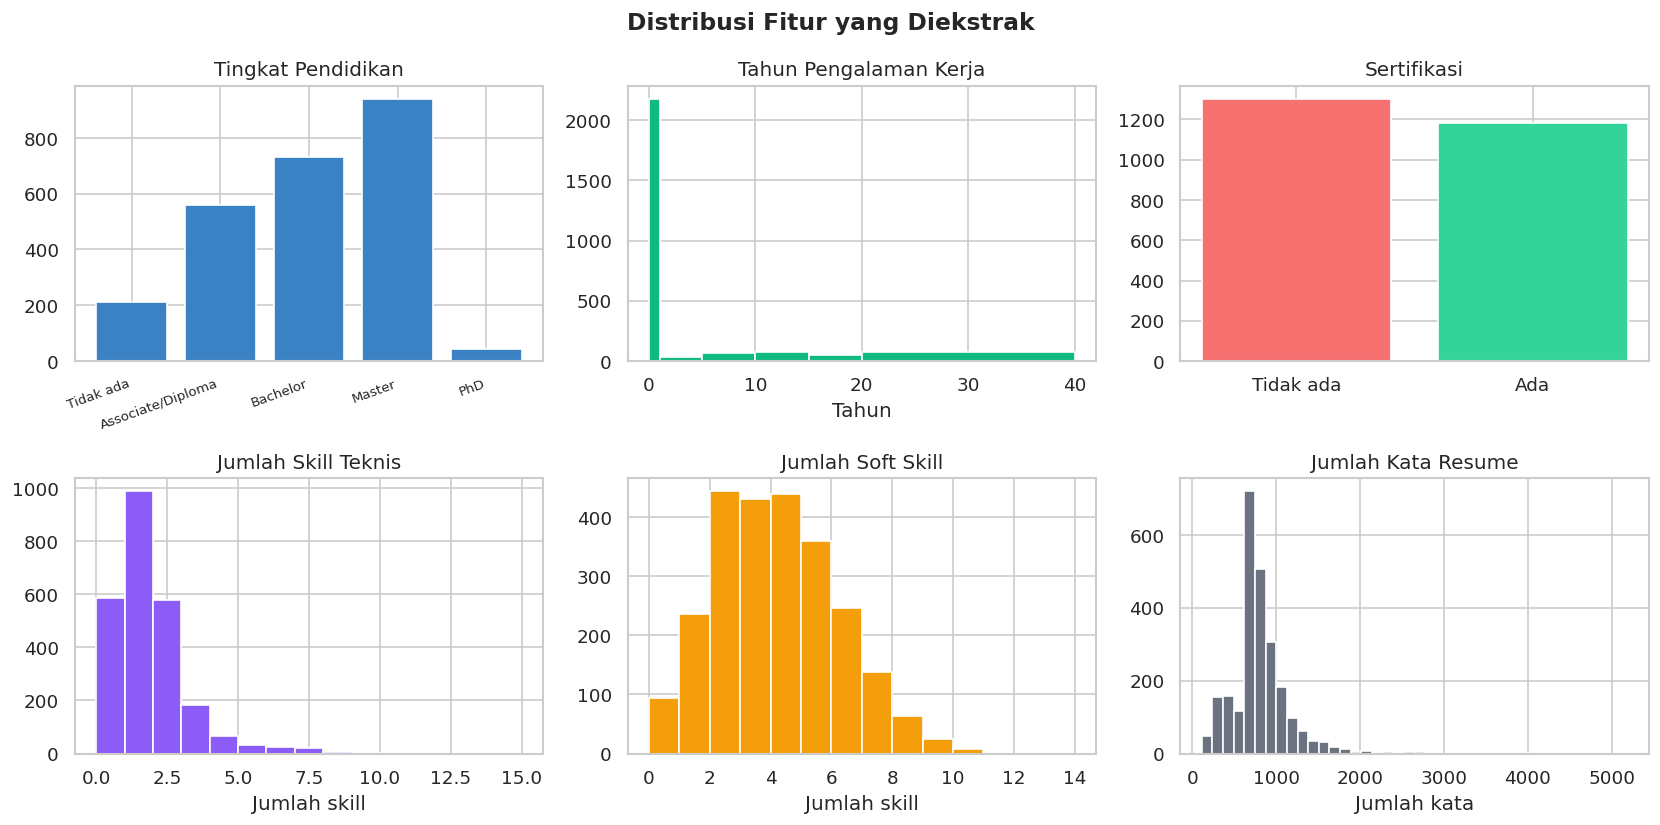

In [13]:
# ── Visualisasi distribusi fitur ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Distribusi Fitur yang Diekstrak', fontsize=14, fontweight='bold')

edu_order = ['Tidak ada','Associate/Diploma','Bachelor','Master','PhD']
edu_counts = df['edu_label'].value_counts().reindex(edu_order).fillna(0)
axes[0,0].bar(edu_order, edu_counts.values, color='#3B82C4')
axes[0,0].set_title('Tingkat Pendidikan')
axes[0,0].set_xticklabels(edu_order, rotation=20, ha='right', fontsize=8)

exp_bins = [0,1,5,10,15,20,40]
axes[0,1].hist(df['years_experience'], bins=exp_bins, color='#10B981', edgecolor='white')
axes[0,1].set_title('Tahun Pengalaman Kerja')
axes[0,1].set_xlabel('Tahun')

cert_counts = df['has_cert'].value_counts()
axes[0,2].bar(['Tidak ada','Ada'], [cert_counts.get(0,0), cert_counts.get(1,0)], color=['#F87171','#34D399'])
axes[0,2].set_title('Sertifikasi')

axes[1,0].hist(df['tech_skill_count'], bins=range(0,16), color='#8B5CF6', edgecolor='white')
axes[1,0].set_title('Jumlah Skill Teknis')
axes[1,0].set_xlabel('Jumlah skill')

axes[1,1].hist(df['soft_skill_count'], bins=range(0,15), color='#F59E0B', edgecolor='white')
axes[1,1].set_title('Jumlah Soft Skill')
axes[1,1].set_xlabel('Jumlah skill')

axes[1,2].hist(df['word_count'], bins=40, color='#6B7280', edgecolor='white')
axes[1,2].set_title('Jumlah Kata Resume')
axes[1,2].set_xlabel('Jumlah kata')

plt.tight_layout()
plt.show()

In [14]:
df.to_csv('Pathora_cleanData.csv', index=False)
